In [25]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris

# metrics
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay                         

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

#Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys
from copy import deepcopy
# =====================================


### Ensemble:

A group of predictors is called an ensemble; thus, this technique is called Ensemble Learning, and an
Ensemble Learning algorithm is called an Ensemble method.

Ensemble methods, including 
- bagging, 
- boosting, 
- stacking, 
- Random Forests.

### Random Forest:

Train a **group of Decision Tree classifiers**, each on a different random subset of the training set. To make predictions, you just obtain the predictions of all individual trees, then predict the class that gets the **most votes** Such an **ensemble of Decision Trees** is called a Random Forest.

### Basice theory about Decisions tree:

TODO

### ***Voting Classifier*** 

Is an ensemble learning method that combines the predictions of multiple base models to improve predictive performance.

Types of Voting:

1. Hard Voting: Each base model casts a single vote for a class label.
2. Soft Voting: Each base model predicts a probability distribution over the class labels, and the class label with the highest average probability is selected.

In Scikit lern:

**VotingClassifier(voting):**

**voting{‘hard’, ‘soft’}, default=’hard’**

If **‘hard’**, uses predicted class labels for majority rule voting. Else if **‘soft’**, predicts the class label based on the argmax of the sums of the predicted probabilities

Hard voting classifier predictions

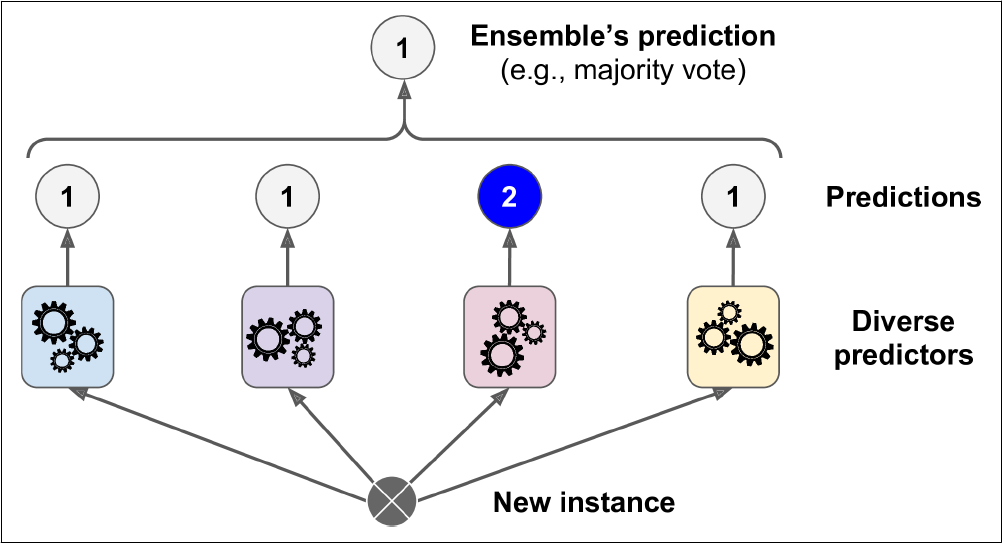


In [3]:
# Get data Set
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
# Get Classifications

log_clf = LogisticRegression(solver="lbfgs", random_state=42)
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf_hard = SVC(gamma="scale", random_state=42) # for hard
svm_clf_soft = SVC(gamma="scale", probability=True, random_state=42)


In [21]:
# Get hards voting
hard_voting_clf = VotingClassifier(
    estimators=[("lr", log_clf), ("rf", rnd_clf), ("svc", svm_clf_hard)],
    voting="hard",
)
hard_voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [22]:
# Get soft voting
soft_voting_clf = VotingClassifier(
    estimators=[("lr", log_clf), ("rf", rnd_clf), ("svc", svm_clf_soft)],
    voting="soft",
)
soft_voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [ ]:
# get voating classifire accuracy
print("Hard Voting Classifier Accuracy: ") 
for clf in (log_clf, rnd_clf, hard_voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

Hard Voting Classifier Accuracy: 
LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.912


In [ ]:
# get voating classifire accuracy
print("Soft Voting Classifier Accuracy: ") 
for clf in (log_clf, rnd_clf, soft_voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

Soft Voting Classifier Accuracy: 
LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.92


### Bagging , Boosting and Pasting

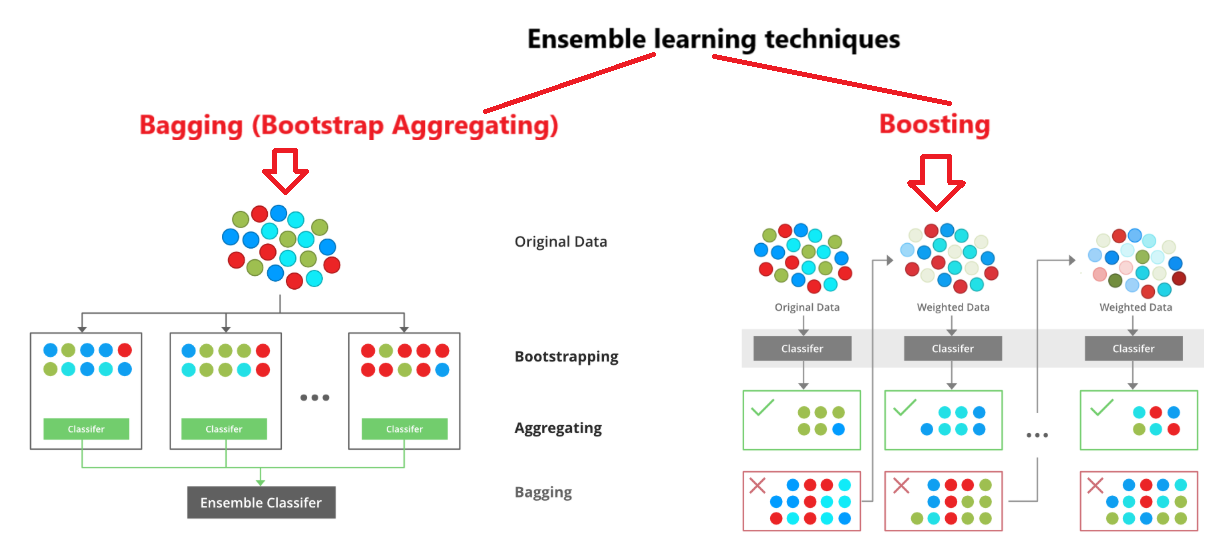

Bagging and Boosting are **ensemble learning** techniques that **combine multiple models** to improve prediction accuracy and robustness in machine learning. 

**Bagging** (Bootstrap Aggregating) ***trains models independently*** on different subsets of the data, aiming 
to ***reduce variance***.

***Pasting*** uses **sampling without replacement**. 

**Boosting**, on the other hand, ***trains models sequentially***, where each subsequent model **corrects the errors of its predecessor**, focusing on reducing bias.

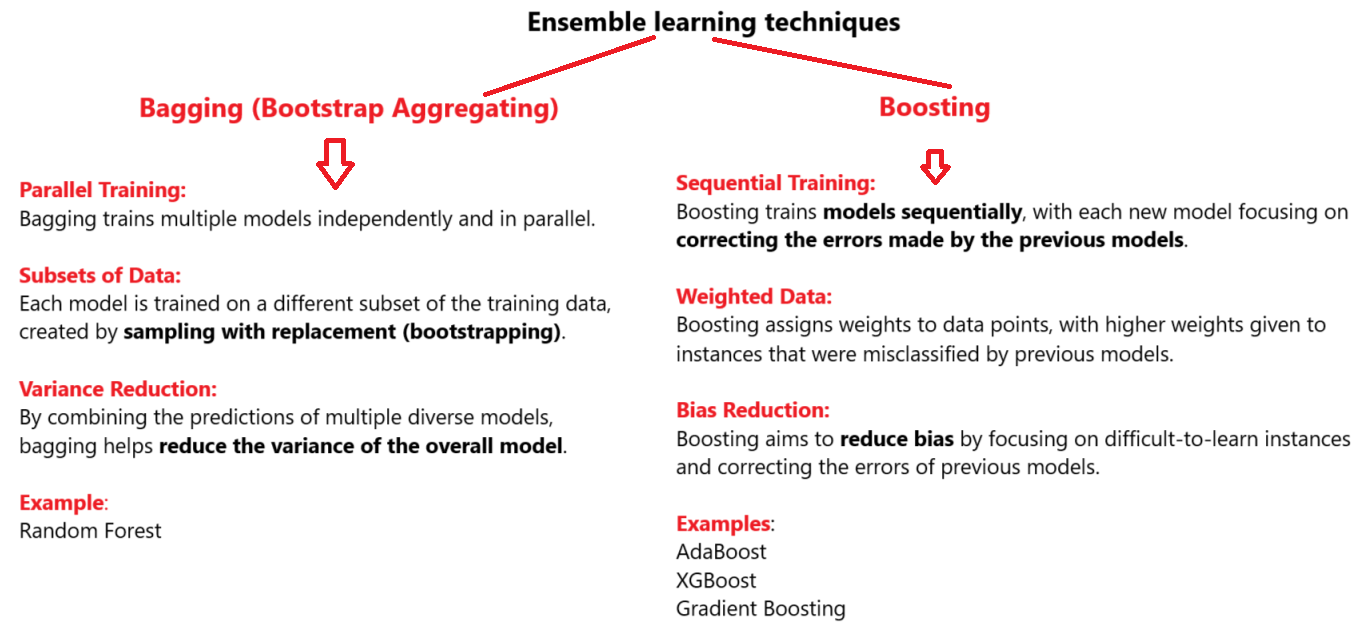

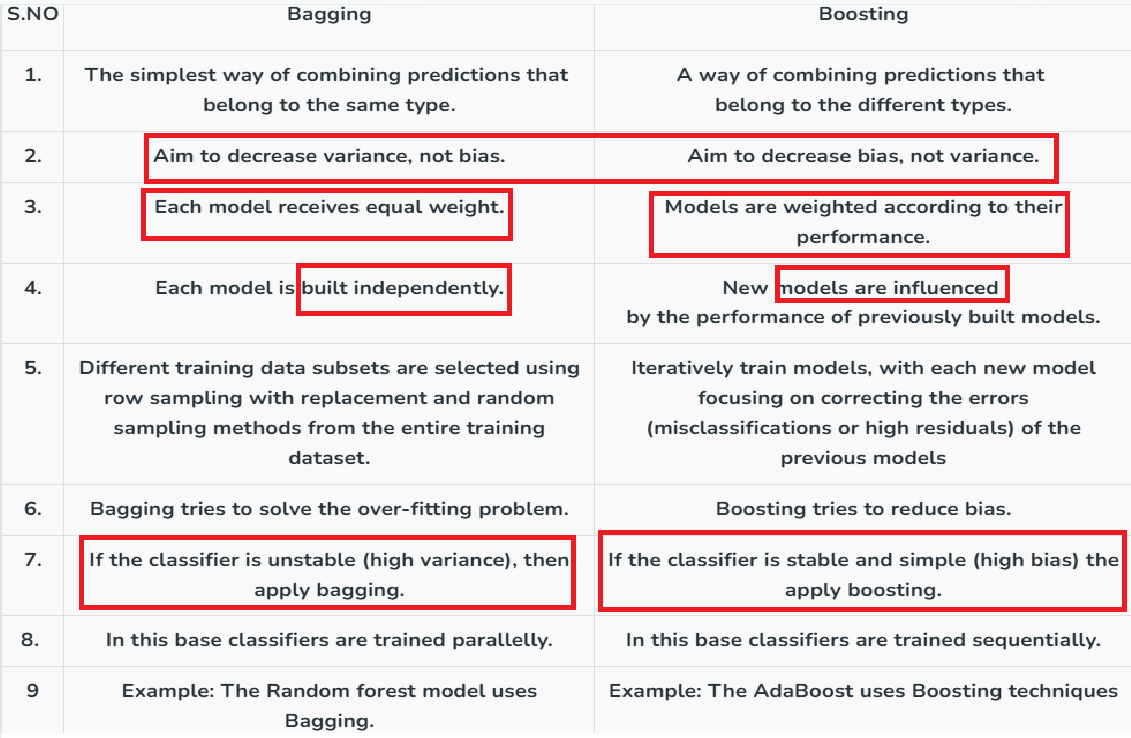

**Some Facts about pesting:**

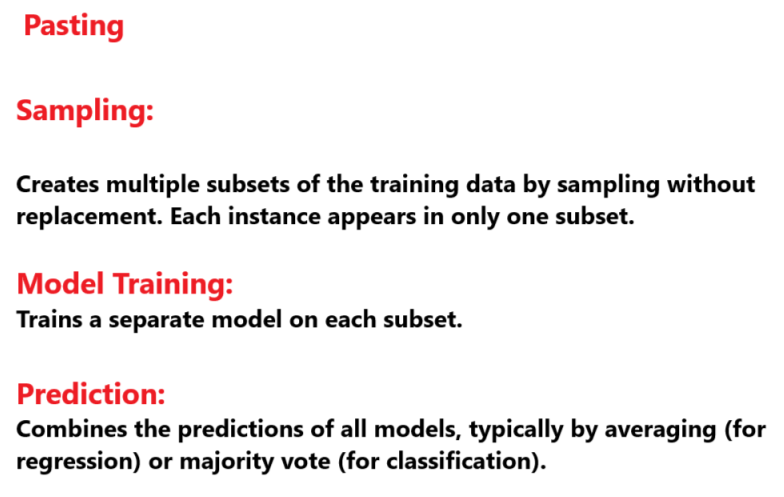


### Implemetations Bagging and Pasting in Scikit-Learn

BaggingClassifier()

Arguments:

1. estimator : object
   
   The base estimator to fit on random subsets of the dataset. Default estimator is a DecisionTreeClassifier.
2. n_estimators: 
  
   number of base estimators in the ensemble. 

   **Example**    if n_estimators = 500, code trains an ensemble of 500 Decision Tree classifiers
3. max_samples: int or float

   The number of samples to draw from X to train each base estimator. 

4. max_features: int or float, default=1.0
   ???

5. bootstrap: 

   if true: Sampling with replacement, i.e. **Bagging** Selected. False **Pesting** selected.

6. n_jobs:
   
   The number of jobs to run in parallel for both fit and predict. **-1** means using all processors. 

7. oob_score:  bool, default=False
   
   Whether to use **out-of-bag samples to estimate** the generalization error. Only a ***vailable if bootstrap=True***.

In [27]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=100, bootstrap=True, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

print('Accuracy score Bagging score: ',accuracy_score(y_test, y_pred))

Accuracy score Bagging score:  0.904


In [28]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=100, bootstrap=False, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

print('Accuracy score Pesting score: ',accuracy_score(y_test, y_pred))

Accuracy score Pesting score:  0.92


In [29]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print('Accuracy score accuracy score: ',accuracy_score(y_test, y_pred_tree))

Accuracy score accuracy score:  0.856


### A single Decision Tree (left) versus a bagging ensemble of 500 trees (right):

TODO

### Out-of-Bag Evaluation

Out-of-Bag (OOB) is a method used to **estimate** the performance of ensemble models, such as ***bagging and random forests***.

#### How OOB Works
1. **Bootstrap sampling:** Create multiple subsets of the training data by ***randomly sampling with replacement***.
2. **Model training:** Train a model on each subset of the data.
3. **OOB instances:** For each model, identify the instances that were not included in the subset (out-of-bag instances).
4. **OOB error:** Calculate the error of the model on the OOB instances.

### Advantages:

1. Unbiased estimate
2. No need for cross-validation


### Qus: Where the Out-of-Bag come from ?

Let BaggingClassifier samples **m** training instances with ***replacement (bootstrap=True)***, where ***m is the size of the training set***. This means that only about ***63%*** of the training instances are sampled on
average for each predictor.
The remaining 37% of the training instances that are not sampled are ***called out-of-bag (oob) instances***.

Note: the 63/37% ratio may be chnaged




In [32]:
bag_clf = BaggingClassifier(
          DecisionTreeClassifier(), n_estimators=500,
          bootstrap=True, oob_score=True, random_state=40)
bag_clf.fit(X_train, y_train)

# Get Score
print('Bagging score: ',bag_clf.oob_score_)

# Get OOB score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

Bagging score:  0.8986666666666666


0.912

### You can Get much more things from return of BaggingClassifier() API

i.e. How to get oob sampls from data set,
     Get estimated sample or get sample on which alkgo applies

### Next: How OOB works ? Step by Step analysis.

### Random Patches and Random Subspaces

Qus: What is controlled hyperparameter in BaggingClassifier(). How they will work?

“Ensembles on Random Patches,” G. Louppe and P. Geurts (2012).
“The random subspace method for constructing decision forests,” Tin Kam Ho (1998).

### Random Forests

For details how random forest works step by step ... you can see state quest video.

I***nstead of building a BaggingClassifier and passing it a DecisionTreeClassifier***, you can instead use the ***RandomForestClassifier*** class, which is *** more convenient and optimized for Decision Trees*** (similarly, there is
a ***RandomForestRegressor class for regression tasks***).

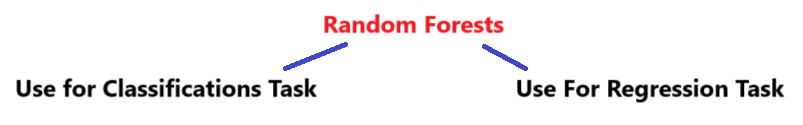


In [33]:
# Code for random forest

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, random_state=42)
rnd_clf.fit(X_train, y_train)

y_pred_rf = rnd_clf.predict(X_test)

### ***Note:*** 
A Random Forest is equivalent to a bag of decision trees:

### Extremely Randomized Trees ensemble

Qus: what is Extra-Trees Classifire ? How this better then Random Forests. Lern Step by Step

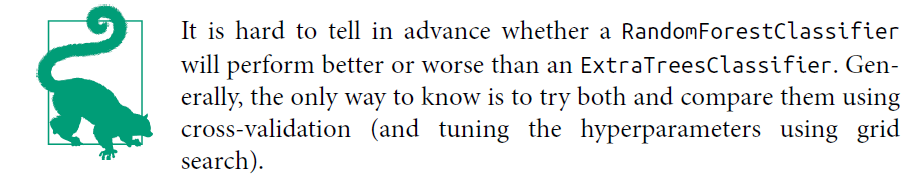

### Feature Importance

##### ***Qus: How to selectect usefull regressions variable in Dataset?***

Use Feature Impotrtance. 
Scikit Lern API

feature_importances_

For Example:

From Iries dataset which one most important features are the petal length  & width, **or** sepal length and width.

##### Result Analysis:

sepal length (cm) 0.10385744081372848
sepal width (cm) 0.02372274969130022
petal length (cm) 0.4201533093879664
petal width (cm) 0.45226650010700487

you can see 
- feature importent of sepal length & width only 10% & 2%.
- feature importent of petal length  & width 42% & 45%.

In [34]:
from sklearn.datasets import load_iris
iris = load_iris()
rnd_clf = RandomForestClassifier(n_estimators=500, n_jobs=-1)
rnd_clf.fit(iris["data"], iris["target"])
for name, score in zip(iris["feature_names"], rnd_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.10385744081372848
sepal width (cm) 0.02372274969130022
petal length (cm) 0.4201533093879664
petal width (cm) 0.45226650010700487


#### **Qus: Find math behind feature importance. How to calculate feature importance ?**

TODO

Use frature Importance on MNIST dataset by using Random Forest classifier and plot each pixel’s importance. You will get image look like below


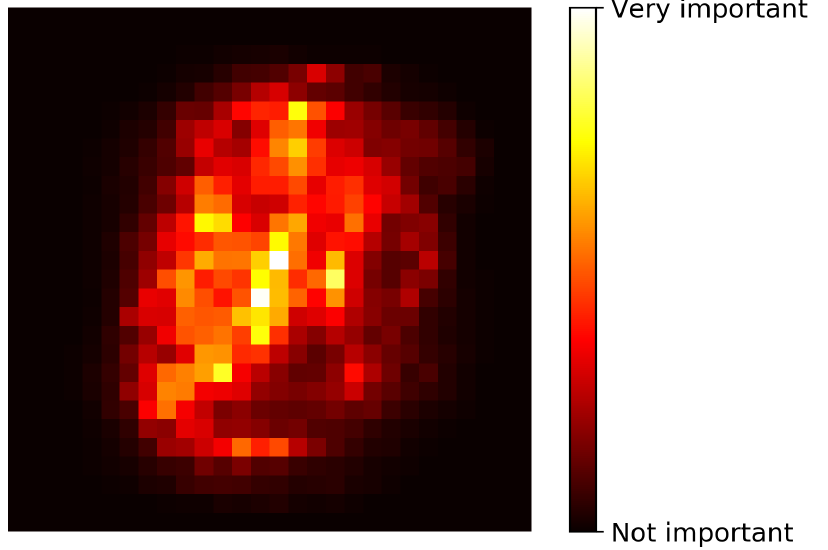

